# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[ResNet-18] Epoch   1/100 | LR: 2.93e-04 | train loss 0.9595 acc 0.618 | val loss 0.7690 acc 0.755 *


[ResNet-18] Epoch   2/100 | LR: 2.93e-04 | train loss 0.8171 acc 0.650 | val loss 1.2418 acc 0.385


[ResNet-18] Epoch   3/100 | LR: 2.93e-04 | train loss 0.7549 acc 0.694 | val loss 0.7963 acc 0.625


[ResNet-18] Epoch   4/100 | LR: 2.93e-04 | train loss 0.7050 acc 0.740 | val loss 0.6161 acc 0.734 *


...

[ResNet-18] Epoch  24/100 | LR: 2.93e-05 | train loss 0.3030 acc 0.885 | val loss 0.4498 acc 0.823


[ResNet-18] Epoch  25/100 | LR: 2.93e-05 | train loss 0.3079 acc 0.897 | val loss 0.3852 acc 0.828


[ResNet-18] Epoch  26/100 | LR: 2.93e-05 | train loss 0.2474 acc 0.907 | val loss 0.4234 acc 0.802


[ResNet-18] Epoch  27/100 | LR: 2.93e-05 | train loss 0.1815 acc 0.939 | val loss 0.4029 acc 0.844


[ResNet-18] Epoch  28/100 | LR: 2.93e-05 | train loss 0.1818 acc 0.929 | val loss 0.4064 acc 0.833

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 28.

[ResNet-18] Restored best checkpoint (val loss = 0.3272)


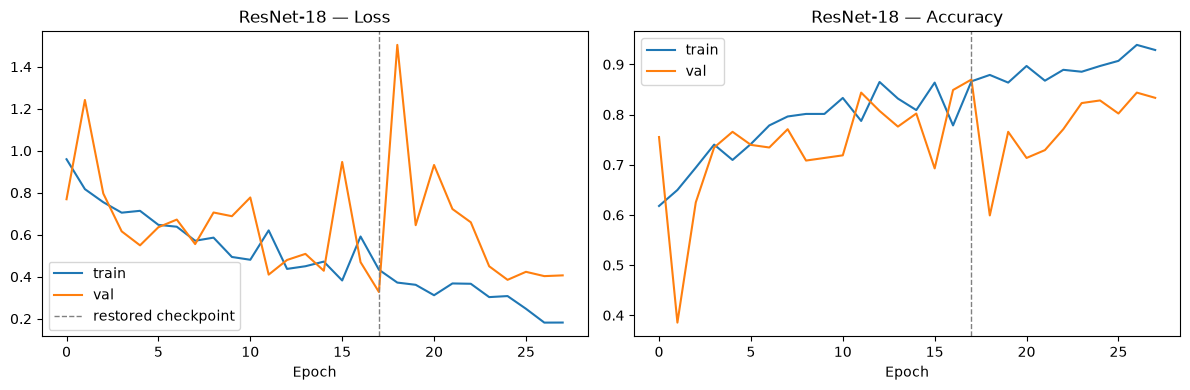

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.548


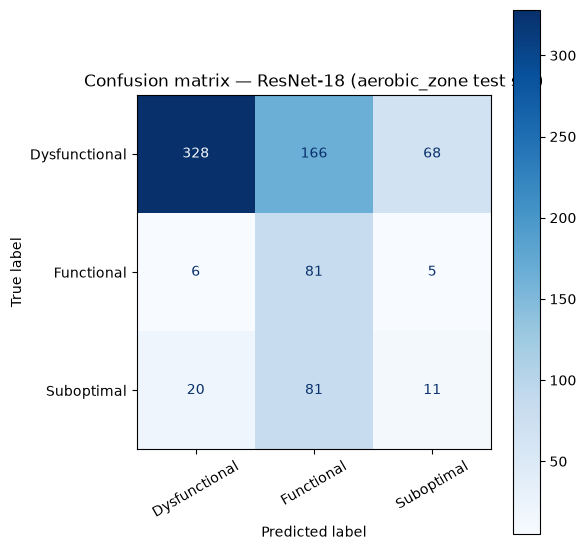

               precision    recall  f1-score   support

Dysfunctional      0.927     0.584     0.716       562
   Functional      0.247     0.880     0.386        92
   Suboptimal      0.131     0.098     0.112       112

     accuracy                          0.548       766
    macro avg      0.435     0.521     0.405       766
 weighted avg      0.729     0.548     0.588       766



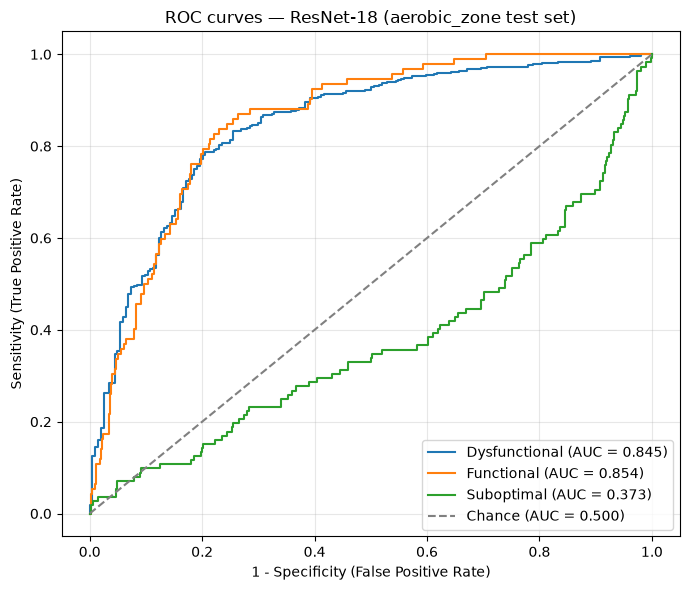

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.845
  Functional     : 0.854
  Suboptimal     : 0.373

Mean AUC (over 3/3 classes with test examples): 0.691


(np.float64(0.5483028720626631),
 {'Dysfunctional': 0.8452480636382667,
  'Functional': 0.8541639788414398,
  'Suboptimal': 0.373307121013543})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet18_CapeFlats.pkl


Saved model weights to ../models/aerobic_zone_resnet18_cnn.pt
